In [1]:
import sys, os
from pathlib import Path
ROOT = Path('.').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import Image, display
%matplotlib inline

from model import Config, build_model
from trainer.trainer import train_model, set_seed
from utils.logging import get_logger
from utils.evaluate import optimize_threshold_rbm
from utils.visualize import (plot_score_distribution, plot_pr_roc_curve,
                              plot_latent_tsne, plot_timeseries_anomaly)
from utils.datasets import load as load_dataset
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (average_precision_score, f1_score,
                             precision_score, recall_score, roc_auc_score,
                             confusion_matrix)

print('torch', torch.__version__, '| cuda available:', torch.cuda.is_available())

torch 2.7.0 | cuda available: False


## 1. Configuration

Edit `DATASET` below to switch between `thyroid` and `creditcard`.

In [2]:
# ---- edit these ----
DATASET = 'thyroid'          # 'thyroid' or 'creditcard'
EPOCHS  = 20
SEED    = 42
LR      = 5e-4
BATCH_SIZE = 512
KL_BETA = 1e-4
LAMBDA_ANOM = 50.0
OUT_DIR = Path('outputs') / 'notebook' / DATASET
# ---------------------

ARCH = {
    'creditcard': {'hidden': 128, 'latent': 32},
    'thyroid':    {'hidden': 32,  'latent': 16},
}
VIZ_CONFIG = {
    'thyroid':    ['score_dist', 'pr_roc'],
    'creditcard': ['score_dist', 'pr_roc', 'tsne', 'timeseries'],
}

assert DATASET in ARCH, f'choose from {list(ARCH)}'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'DATASET={DATASET}  EPOCHS={EPOCHS}  OUT_DIR={OUT_DIR}')

DATASET=thyroid  EPOCHS=20  OUT_DIR=outputs/notebook/thyroid


## 2. Load data

In [3]:
d = load_dataset(DATASET)
xtr = d['x_train'].numpy(); ytr = d['y_train'].numpy().astype(np.int64)
xval = d['x_val'].numpy();  yval = d['y_val'].numpy().astype(np.int64)
xte = d['x_test'].numpy();  yte = d['y_test'].numpy().astype(np.int64)
dim = int(xtr.shape[1])
arch = ARCH[DATASET]

pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'n': [len(xtr), len(xval), len(xte)],
    'anomaly': [int(ytr.sum()), int(yval.sum()), int(yte.sum())],
    'normal': [int((ytr==0).sum()), int((yval==0).sum()), int((yte==0).sum())],
})


,split,n,anomaly,normal
0,train,3634,24,3610
1,val,92,46,46
2,test,46,23,23


## 3. Build model

In [4]:
cfg = Config(
    input_dimension=dim, hidden_dim=arch['hidden'],
    num_var1=arch['latent'], num_var2=arch['latent'],
    lambda_anom=LAMBDA_ANOM, kl_beta=KL_BETA, lr=LR,
    batch_size=BATCH_SIZE, epochs=EPOCHS, seed=SEED,
    out_dir=str(OUT_DIR),
)
set_seed(cfg.seed)
model = build_model(cfg)
print(model)

2026-09-23 17:54:44,051 - model — INFO — [build] input=6 hidden=32 RBM=16x16 params=6,390


CleanEnergyQVAE(in=6, hidden=32, RBM=16x16, lambda=50.0, neg_phase=sampled)


## 4. Train

In [5]:
model, best = train_model(model, cfg, xtr, ytr, xval, yval,
                          tag=f'qvae_{DATASET}', log_file=None)
print(f'\nBest epoch={best["epoch"]}  valPR(energy)={best["val_pr"]:.4f}')

qvae_thyroid:   0%|                                                          | 0/20 [00:00<?, ?it/s]

qvae_thyroid:   0%|                              | 0/20 [00:01<?, ?it/s, loss=175.258, valPR=0.9949]

2026-09-23 17:54:47,476 - trainer — INFO — [qvae_thyroid] epoch 1/20 loss=175.2580 valPR(energy)=0.9949 recon=0.3131 comb=0.9475


qvae_thyroid:   5%|█                     | 1/20 [00:01<00:25,  1.34s/it, loss=175.258, valPR=0.9949]

qvae_thyroid:   5%|█                     | 1/20 [00:01<00:25,  1.34s/it, loss=179.633, valPR=0.9944]

...

2026-09-23 17:54:51,939 - trainer — INFO — [qvae_thyroid] epoch 20/20 loss=55.0441 valPR(energy)=0.9973 recon=0.3131 comb=0.9753


qvae_thyroid: 100%|██████████████████████| 20/20 [00:05<00:00,  4.10it/s, loss=55.044, valPR=0.9973]

qvae_thyroid: 100%|██████████████████████| 20/20 [00:05<00:00,  3.45it/s, loss=55.044, valPR=0.9973]

2026-09-23 17:54:51,941 - trainer — INFO — [qvae_thyroid] best epoch=11 valPR=0.9973



Best epoch=11  valPR(energy)=0.9973


In [6]:
ckpt_path = OUT_DIR / f'{DATASET}.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'config': vars(cfg),
    'best_epoch': best['epoch'],
    'best_val_pr': best['val_pr'],
    'scaler': d.get('scaler'),
}, ckpt_path)
print('Saved checkpoint:', ckpt_path)

Saved checkpoint: outputs/notebook/thyroid/thyroid.pt


## 5. Evaluate

Reload checkpoint (simulates a fresh evaluation run) and pick the best F1 threshold on the validation split.

In [7]:
ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
cfg2 = Config(**ckpt['config'])
model = build_model(cfg2)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
device = cfg2.device
print(f'Loaded best epoch={ckpt["best_epoch"]}  valPR={ckpt["best_val_pr"]:.4f}  device={device}')

2026-09-23 17:54:51,961 - model — INFO — [build] input=6 hidden=32 RBM=16x16 params=6,390


Loaded best epoch=11  valPR=0.9973  device=cpu


In [8]:
def fe(xb):
    with torch.no_grad():
        return model.get_score_energy(xb.to(device)).cpu()

val_loader = DataLoader(TensorDataset(torch.from_numpy(xval), torch.from_numpy(yval)),
                        batch_size=2048, shuffle=False)
th = optimize_threshold_rbm(fe, val_loader, device,
                           search_mode='grid', n_candidates=200, metric='f1')
print(f'Chosen threshold (best F1 on val): {th:.4f}')

with torch.no_grad():
    e_te = model.get_score_energy(torch.from_numpy(xte).to(device)).cpu().numpy()
pred = (e_te > th).astype(int)

Chosen threshold (best F1 on val): -13.3232


In [9]:
metrics = {
    'pr_auc':   float(average_precision_score(yte, e_te)),
    'roc_auc':  float(roc_auc_score(yte, e_te)),
    'precision':float(precision_score(yte, pred, zero_division=0)),
    'recall':   float(recall_score(yte, pred, zero_division=0)),
    'f1':       float(f1_score(yte, pred, zero_division=0)),
}
cm = confusion_matrix(yte, pred)
pd.Series(metrics, name=f'cleanqvae / {DATASET}').to_frame().round(4)

,cleanqvae / thyroid
pr_auc,0.9929
roc_auc,0.9924
precision,0.9545
recall,0.9130
f1,0.9333


## 6. Visualizations

Plots for thyroid : ['score_dist', 'pr_roc']


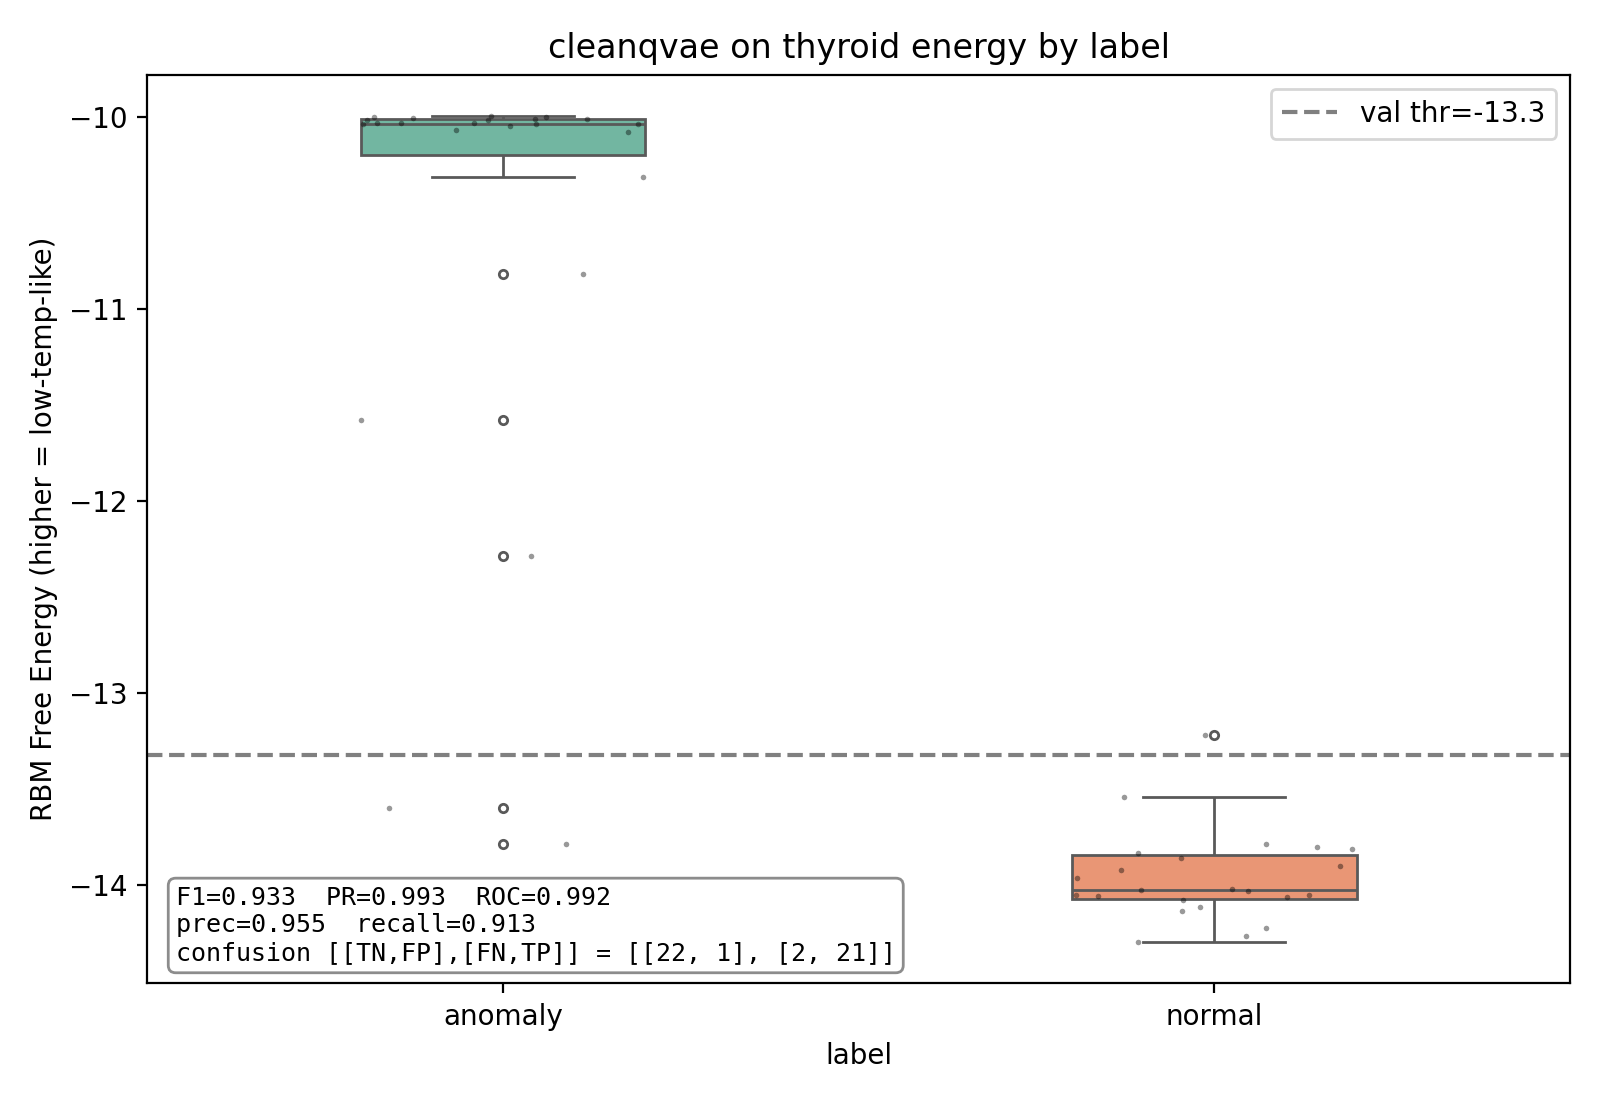

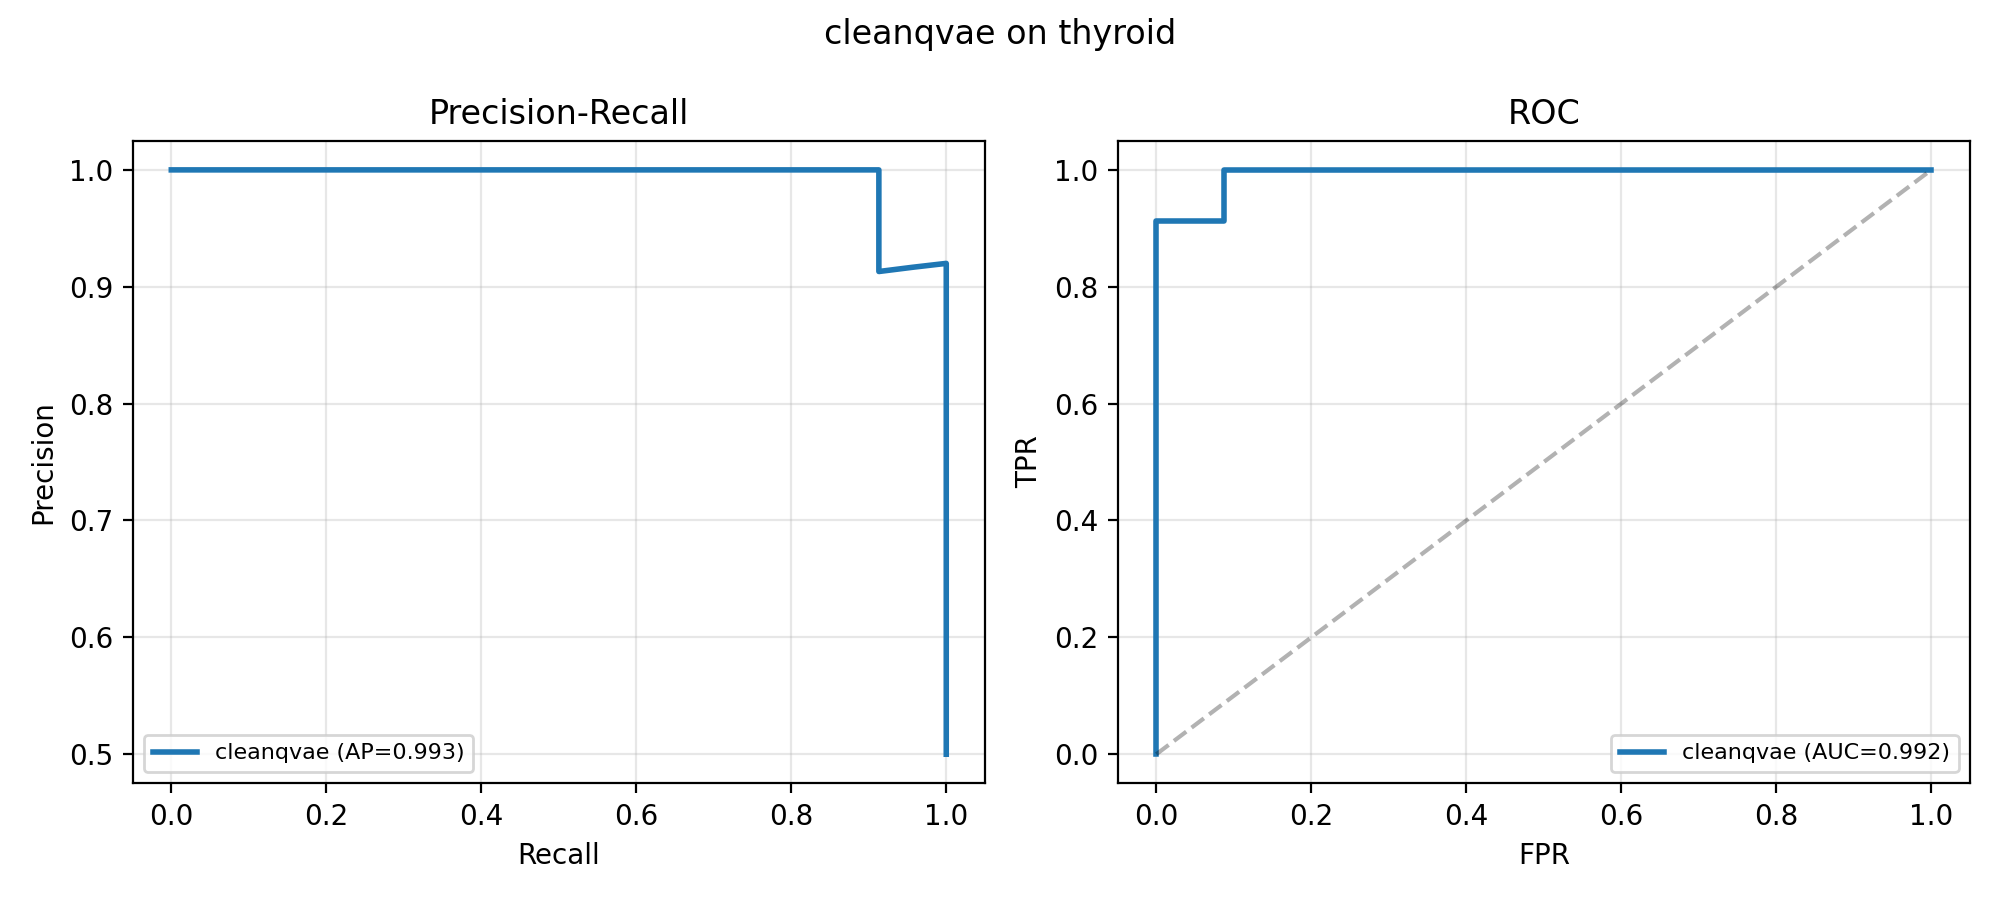

In [10]:
viz_list = VIZ_CONFIG[DATASET]
print('Plots for', DATASET, ':', viz_list)

if 'score_dist' in viz_list:
    plot_score_distribution(e_te, yte, th, metrics, cm,
                           OUT_DIR / 'score_distribution.png',
                           title=f'cleanqvae on {DATASET} energy by label',
                           label_low='anomaly', label_normal='normal')
    display(Image(filename=str(OUT_DIR / 'score_distribution.png')))

if 'pr_roc' in viz_list:
    plot_pr_roc_curve(yte, e_te, OUT_DIR / 'pr_roc_curve.png',
                      title=f'cleanqvae on {DATASET}', label='cleanqvae')
    display(Image(filename=str(OUT_DIR / 'pr_roc_curve.png')))


In [12]:
if 'tsne' in viz_list and hasattr(model, 'encoder'):
    with torch.no_grad():
        z = model.encoder(torch.from_numpy(xte).to(device)).cpu().numpy()
    rng = np.random.RandomState(42)
    n_show = min(5000, len(z))
    idx = rng.choice(len(z), n_show, replace=False)
    plot_latent_tsne(z[idx], yte[idx], OUT_DIR / 'latent_tsne.png',
                     title=f'cleanqvae on {DATASET} latent t-SNE (n={n_show})')
    display(Image(filename=str(OUT_DIR / 'latent_tsne.png')))

if 'timeseries' in viz_list:
    time = xte[:, 0]
    plot_timeseries_anomaly(time, e_te, yte, th, OUT_DIR / 'timeseries_anomaly.png',
                            title=f'cleanqvae on {DATASET} energy vs time')
    display(Image(filename=str(OUT_DIR / 'timeseries_anomaly.png')))
